In [201]:
#### Importando modulos 
import pandas as pd
import numpy as np
import scipy
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [202]:
##### Funcion para integrar posiciones
def posiciones(df_r: pd.DataFrame, empresas: list[str], tipo:str):
    df_posiciones = pd.DataFrame()
    #### Extracciones individuales
    if tipo=='sliding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'SlidingFinalPreds/pred_sliding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='expanding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'ExpandingFinalPreds/pred_expanding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='todo':
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [1] * df_r.shape[0]
    elif tipo=='rand':
        import random
        random.seed(42)
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [random.randint(0,1) for _ in range(df_r.shape[0])]


    #### Asegurando que df_posiciones tenga mismo numero de datos
    df_posiciones = df_posiciones.iloc[:df_r.shape[0]]

    #### Camiando indices
    df_posiciones.index = df_r.index
    
    #### Sumando cantidad de posiciones
    suma = df_posiciones.sum(axis=1)

    #### Asignando posiciones equitativamente
    df_posiciones_finales = df_posiciones.div(suma, axis=0)

    #### Integrando posiciones con rendimientos
    df_integrado = pd.concat([df_r,df_posiciones_finales], axis=1, ignore_index=False)

    return df_integrado


In [203]:
##### Calculando formula para la rentabilidad del portafolio

def calc_rentabilidad(df:pd.Dataframe, empresas: list[str], tgt: int = 0.1, costo : int = 0.00001) -> pd.Dataframe:
    """
    Formula para calcular la rentabilidad de un portafolio 

    Params:
    df: el dataframe que contiene los rendimientos, EWMSD, y posiciones del portafolio
    tgt: la voltatilidad deseada para escalar la volatilidad proporcionalmente
    costo: costo de cambiar las posiciones de las acciones en un portafolio

    Return:
    df_rentabilidad: el df que contiene la rentabilidad del portafolio por las fechas marcadas
    """
    #### Calculando rentabilidad equitativa por cada accion/empresa
    df_rentabilidad = pd.DataFrame()
    for name in empresas:
        df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * (tgt/df[f'EWMSD.{name}'].shift(1))  * df[f'Posicion.{name}'].shift(1) - \
        costo*abs(((tgt/df[f'EWMSD.{name}'].shift(1))*df[f'Posicion.{name}'].shift(1)) - ((tgt/df[f'EWMSD.{name}'].shift(2))*df[f'Posicion.{name}'].shift(2)))
        # df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * df[f'Posicion.{name}']


    #### Elimando primera dos fila por el "shift(2)"
    df_rentabilidad_diaria = df_rentabilidad.iloc[2:]

    return df_rentabilidad_diaria



In [204]:
#### Formula para limpiar datos
def cargar(nom: str, tipo: str):
    ### Cargando datos
    df = pd.read_csv(nom, index_col='Date')

    ### Nombre de las 32 empresas
    empresas = df.columns.to_list()

    ### Calculando EWMSD
    for name in empresas:
        df[f'EWMSD.{name}'] = df[name].ewm(span=30, adjust=False).std()

    ### Eliminando datos
    df = df.iloc[:-62]
    df = df.iloc[345:]

    #### Calculando posiciones
    df_posiciones= posiciones(df, empresas, tipo)    

    #### Calculado rentabilidades diarias de todas acciones
    df_rentabilidad_diaria = calc_rentabilidad(df_posiciones, empresas)
    
    return df_rentabilidad_diaria

In [205]:
#### Funcion para extraer estadisticas
def estadisticas(df:pd.DataFrame):
    ### Creando arreglo de estadisticas
    arr = []
    arr.append(int(df.shape[0]))
    arr.append(df.mean().round(4).item())    # Promedio
    arr.append(df.median().round(4).item())  # Mediana
    arr.append(df.std(ddof=0).round(4).item())   # Des Est
    arr.append(df.min().round(4).item())     # Minimo
    arr.append(df.max().round(4).item())     # Maximo

    return arr

    # ### Buscando el exponente comun
    # arr = np.array(arr, dtype=float)
    # exponentes = np.floor(np.log10(np.abs(arr)))
    # exp_comun = int(scipy.stats.mode(exponentes)[0])

    # ### Ajustando valores
    # resultados = arr/(10**exp_comun)
    # resultados = np.round(resultados, 2)
    # resultados = [int(df.shape[0])] + resultados.tolist()

    # return (resultados, exp_comun)

In [227]:
#### Ajustando datos
def ajustar(df: pd.DataFrame):
    arr = df.values
    exponentes = np.floor(np.log10(np.abs(arr)))
    exp_comun = int(scipy.stats.mode(exponentes)[0])

    ### Ajustando valores
    resultados = arr/(10**exp_comun)
    resultados = np.round(resultados, 2)

    return pd.DataFrame(resultados), exp_comun
    

In [ ]:
#### Funcion para extraer data de rendimiento esperado, vol, y ratio sharpe
def test(df_inicial: pd.DataFrame, df_final: pd.DataFrame):
    ### Indice de REndimiento    
    df_inicial_rend = df_inicial.mean(axis=0)
    df_final_rend = df_final.mean(axis=0)
    df_indice_rend = (df_final_rend - df_inicial_rend)/(df_inicial_rend.abs() + 1e-8)

    ### Indice de Volatilidad
    df_inicial_vol = df_inicial.std(axis=0, ddof=0)
    df_final_vol = df_final.std(axis=0, ddof=0)
    df_indice_vol = (df_final_vol - df_inicial_vol)/(df_inicial_vol + 1e-8)

    ### Ratio Sharpe
    df_ratio_sharpe = df_indice_rend/(df_indice_vol + 1e-8)


    ### Copiando datos
    # df_inicial_rend.to_clipboard(header=False,index=False)
    # df_copy, exp = ajustar(df_final_vol)
    # df_copy.to_clipboard(header=False,index=False)
    # print(exp)



    ### Ratio Sharpe
    # df_rendis_esperado = df_final.mean(axis=0)
    # df_vol = df_final.std(axis=0, ddof=0)
    # df_ratio_sharpe = df_rendis_esperado/(df_vol + 1e-8)

    return df_indice_rend, df_indice_vol, df_ratio_sharpe

In [247]:
#### Fucnion de visualizacion: tabla y bargraph
def visuales(pre_datos: list, post_datos: list, nom:str):
    ### Uniendo los datos
    data = [pre_datos, post_datos]

    ### Tabla
    ## Nombre de columnas y filas
    cols = ['N', 'Media', 'Mediana', 'Des.Est', 'Mínimo', 'Máximo']
    rows = ['Pre-LSTM', 'Post-LSTM']

    ## Cofigurando tabla
    ANCHURA = 7
    ALTURA = 4
    fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,
        colLabels=cols,
        colColours=["#13a82c"]*len(cols),
        rowLabels=rows,
        rowColours=["#1cb4a8"] * len(rows),
        loc='center',
        cellLoc='center'
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    ax.set_title(f"Estadística - {nom}", fontweight="bold", fontsize=14)
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)

    plt.show()


    ### Bar graph
    ## Hiperparams
    ANCHURA = 10
    ALTURA = 5
    WIDTH = 0.25
    ## Configurando datos
    data = np.array([pre_datos[1:], post_datos[1:]])
    cols = ['Pre-LSTM', 'Post-LSTM']
    x_idxs = ['Media', 'Mediana', 'Des.Est', 'Mínimo', 'Máximo']
    x = np.arange(len(x_idxs))   # Se hace para el pretest y posttest
    fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
    for i, col in enumerate(cols):
        ax.bar(x + i * WIDTH, data[i], WIDTH, label = col, edgecolor='black')

    ## Configurando grafo
    ax.set_xlabel(f'Estadística', fontsize=ANCHURA, fontweight="bold")
    ax.set_ylabel(f'Valores', fontsize=ANCHURA, fontweight="bold")
    ax.set_title(f'Estadística - {nom}', fontsize=ANCHURA, fontweight="bold")
    ax.set_xticks(x + WIDTH)
    ax.set_xticklabels(x_idxs)
    ax.grid(True, axis='y')
    ax.tick_params(axis='x', labelsize=0.8*ANCHURA) 
    ax.tick_params(axis='y', labelsize=0.85*ANCHURA) 
    ax.legend(fontsize=ANCHURA)



In [208]:
##### Extrayendo informacion
def distribucion(data1: list, data2:list, nom:str):
    ### Creando histograma
    ANCH = 12
    ALT = 5
    fig, axs = plt.subplots(1,2, figsize=(ANCH, ALT), sharex=False, sharey=False)
    
    ### Histograma 1
    ## Histograma mismo
    min_val = min(data1)
    max_val = max(data1)
    num_centros = int(1 + (np.log(len(data1))/ np.log(2)))
    centros = np.linspace(min_val, max_val, num_centros)
    cuentas, bordes, parches = axs[0].hist(data1, bins=centros, edgecolor='black')

    ## Configuranciones 
    axs[0].set_title(f'Distribución {nom}: Pre-test', fontweight='bold')
    axs[0].set_xlabel(f'Rango de Valores', fontweight='bold', fontsize=ANCH)
    axs[0].set_ylabel('Frecuencia de Valores en Rango', fontweight='bold', fontsize=ANCH)

    ## Arreglando eje x
    bordes_rangos = [f"{(bordes[i].round(1))}–\n{(bordes[i+1].round(1))}" for i in range(len(bordes)-1)]
    axs[0].set_xticks((bordes[:-1] + bordes[1:])/2)
    axs[0].set_xticklabels(bordes_rangos)

    
    ### Histograma 2
    ## Histograma mismo
    min_val = min(data2)
    max_val = max(data2)
    num_centros = int(1 + (np.log(len(data2))/ np.log(2)))
    centros = np.linspace(min_val, max_val, num_centros)
    cuentas, bordes, parches = axs[1].hist(data2, bins=centros, edgecolor='black')

    ## Configuranciones 
    axs[1].set_title(f'Distribución {nom}: Post-test', fontweight='bold')
    axs[1].set_xlabel(f'Rango de Valores', fontweight='bold', fontsize=ANCH)
    axs[1].set_ylabel('Frecuencia de Valores en Rango', fontweight='bold', fontsize=ANCH)
    axs[1].yaxis.set_major_locator(MaxNLocator(integer=True))
    
    ## Arreglando eje x
    bordes_rangos = [f"{(bordes[i].round(1))}–\n{(bordes[i+1].round(1))}" for i in range(len(bordes)-1)]
    axs[1].set_xticks((bordes[:-1] + bordes[1:])/2)
    axs[1].set_xticklabels(bordes_rangos)



In [209]:
#### Funcion para medir la normalidad
def normalidad(ds_pre: list, ds_post: list, nom: str):
    # ### Transformando dataframes a arreglos
    # arr_pre = ds_pre.to_list()
    # arr_post = ds_post.to_list()
    # arr_diff = ds_post.values - ds_pre.values
    # arr_diff = arr_diff.tolist()

    ### Haciendo pruebas
    pre_estad, pre_pvalor = stats.kstest(ds_pre, 'norm')
    post_estad, post_pvalor = stats.kstest(ds_post, 'norm')
    # diff_estad, diff_pvalor = stats.kstest(arr_diff, 'norm')

    ### Arreglando formato de numeros
    pre_pvalor = format(pre_pvalor, '.3e')
    post_pvalor = format(post_pvalor, '.3e')
    # diff_pvalor = format(diff_pvalor, '.3e')
    pre_estad = pre_estad.round(3)
    post_estad = post_estad.round(3)
    # diff_estad = diff_estad.round(5)

    ### Visualizacion Tabla
    ## Preparacion
    data = [[32, pre_estad, pre_pvalor],[32, post_estad, post_pvalor]]#, [32, diff_estad, diff_pvalor]]
    cols = ['N', 'Estadístico', 'P-valor']
    rows = [f'Pre-{nom}', f'Pos-{nom}']#, 'Diferencia']

    ## Configurando tabla
    ANCHURA = 7
    ALTURA = 4
    fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,
        cellColours=[['white','white','yellow']] * len(data), 
        colLabels=cols,
        colColours=["#e9820d"]*len(cols),
        colWidths=[0.2, 0.2, 0.2],
        rowLabels=rows,
        rowColours=["#1cb4a8"] * len(rows),
        loc='center',
        cellLoc='center'
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    ax.set_title(f"KS Prueba de Normalidad - {nom}", fontweight="bold", fontsize=14)
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)

    plt.show()

In [210]:
#### Formula para prueba de Wilcoxon
def wilcoxon(ds_pre: pd.Series, ds_post: pd.Series, nom: str):
    ### Transformando dataframes a arreglos
    arr_diff = ds_post.values - ds_pre.values
    arr_diff = arr_diff.tolist()

    ### Realizando prueba
    if nom.lower() == 'rendimiento': estad, pvalor = stats.wilcoxon(arr_diff, alternative='greater')
    elif nom.lower() == 'volatilidad': estad, pvalor = stats.wilcoxon(arr_diff, alternative='less')

    ### Arreglando formato de numeros
    estad = estad.round(5)
    # pvalor = pvalor.round(10)
    pvalor = format(pvalor, '.3e')

    ### Visualizacion tabla
    data = [[32, estad, pvalor]]
    cols = ['N', 'Estadístico', 'P-valor']
    rows = [f'Post-{nom} - \nPre-{nom}']

    ## Configurando tabla
    ANCHURA = 7
    ALTURA = 4
    fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,
        cellColours=[['white','white','yellow']],
        colLabels=cols,
        colColours=["#e9820d"]*len(cols),
        colWidths=[0.2, 0.2, 0.2],
        rowLabels=rows,
        rowColours=["#1cb4a8"] * len(rows),
        loc='center',
        cellLoc='center'
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    ax.set_title(f"Prueba Wilcoxon - {nom}", fontweight="bold", fontsize=14)
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)

    plt.show()


In [211]:
#### Cargar datos
nom_excel = 'retornos.csv'
rend_diaria_original_rand = cargar(nom_excel, 'rand')
rend_diaria_original_lstm = cargar(nom_excel, 'sliding')
rend_diaria_original_todo = cargar(nom_excel, 'todo')

In [428]:
#### Grafos finales de crecimiento
def crecimientos(df_pre:pd.DataFrame, df_post: pd.DataFrame, nom:str):
    #### Arreglando nombres
    empresas = df_pre.index.to_list()
    empresas = [word.split('.')[1] for word in empresas]
    print(empresas)

    #### Ajustando datos
    df_pre_aju, pre_exp = ajustar(df_pre)
    df_post_aju, post_exp = ajustar(df_post)

    # display(df_pre_aju)
    # display(df_post_aju)

    if pre_exp != post_exp:
        if abs(pre_exp) > abs(post_exp):
            diff = post_exp-pre_exp
            df_post_aju = df_post_aju * 10**diff
            post_exp = pre_exp
        else:
            diff = pre_exp - post_exp
            df_pre_aju = df_pre_aju * 10**diff
            pre_exp = post_exp
    
    # display(df_pre_aju)
    # display(df_post_aju)
  
    
        # diff = post_exp-pre_exp if abs(pre_exp) > abs(post_exp) else pre_exp-post_exp

    
    #### Calculando promedio
    promedio_pre = df_pre_aju.mean(axis=0)
    promedio_post = df_post_aju.mean(axis=0)

    #### Creando grafo de promedio
    ANCH = 12
    ALT = 5
    fig,ax = plt.subplots(figsize = (ANCH,ALT))
    categorias = ['Promedio \nPre-Test', 'Promedio \nPost-Test']
    valores = [
        round(promedio_pre.values[0],2), 
        round(promedio_post.values[0],2)
    ]
    ax.barh(
        categorias, valores, 
        color=["blue", "orange"], 
        edgecolor="black",
        height=0.7
    )

    ## Configuraciones
    for i, v in enumerate(valores):
        ax.text(v + 0.05, i, str(v), va='center', fontsize=ANCH, fontweight='bold')
    ax.set_xlabel(f"Valor (*e{pre_exp})", fontsize=ANCH, fontweight="bold")
    ax.set_ylabel("Categoría", fontsize=ANCH, fontweight="bold")
    ax.set_ylim(-0.5, len(categorias)-0.5)
    ax.set_title(f'Promedios de {nom}', fontsize=ANCH, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.7)
    plt.show()


    ### Creando bargraph completo
    ANCH = 25
    ALT = 12
    WIDTH = 0.25
    ## Configurando datos
    data = np.array([df_pre_aju.values.flatten(), df_post_aju.values.flatten()])
    bars = ['Pre-test', 'Post-test']
    x = np.arange(len(empresas))
    fig, ax = plt.subplots(figsize=(ANCH,ALT))
    for i, col in enumerate(bars):
        ax.bar(x + i * WIDTH, data[i], WIDTH, label = col, edgecolor='black')

    ## Configuraciones
    ax.set_xlabel(f'Empresas', fontsize=ANCH, fontweight="bold", labelpad=15)
    ax.set_ylabel(f'Valores (*e{pre_exp})', fontsize=ANCH, fontweight="bold")
    ax.set_title(f'{nom}: Pre-Test vs Post-Test', fontsize=ANCH, fontweight="bold")
    ax.set_xticks(x + WIDTH)
    ax.set_xticklabels(empresas, rotation=90)
    ax.grid(True)
    ax.tick_params(axis='x', labelsize=0.8*ANCH) 
    ax.tick_params(axis='y', labelsize=0.85*ANCH) 
    ax.legend(fontsize=ANCH)

    

-3
-3
['ABEV', 'AC', 'AMXB', 'AXIA3', 'BAP', 'BBAS3', 'BBD', 'BIMBOA', 'BSAC', 'CEMEXCPO', 'CENCOSUD', 'CIB', 'FALABELLA', 'FEMSAUBD', 'GCARSOA1', 'GFNORTEO', 'GGB', 'GMEXICOB', 'ISA', 'ITSA4', 'ITUB', 'PAC', 'PBR', 'PBR-A', 'RENT3', 'SBSP3', 'SCCO', 'SQM', 'VALE', 'VIV', 'WALMEX', 'WEGE3']


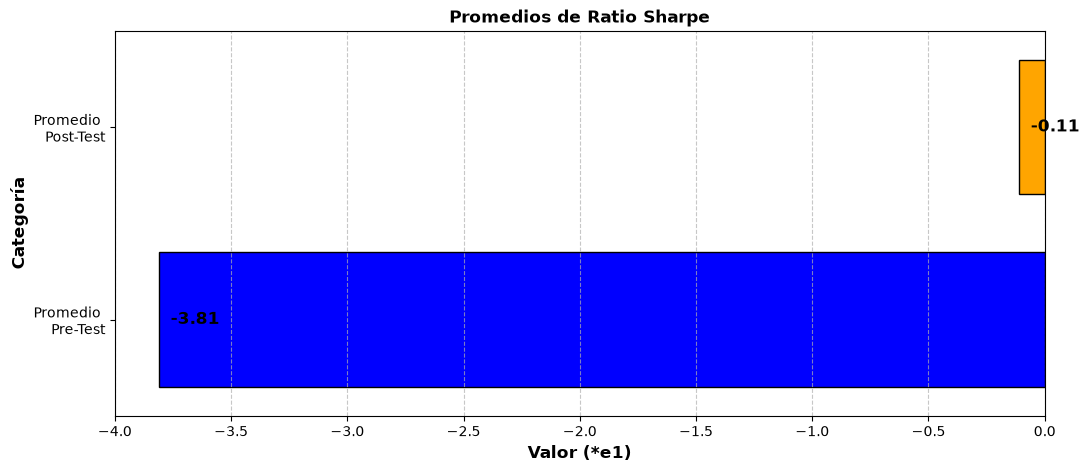

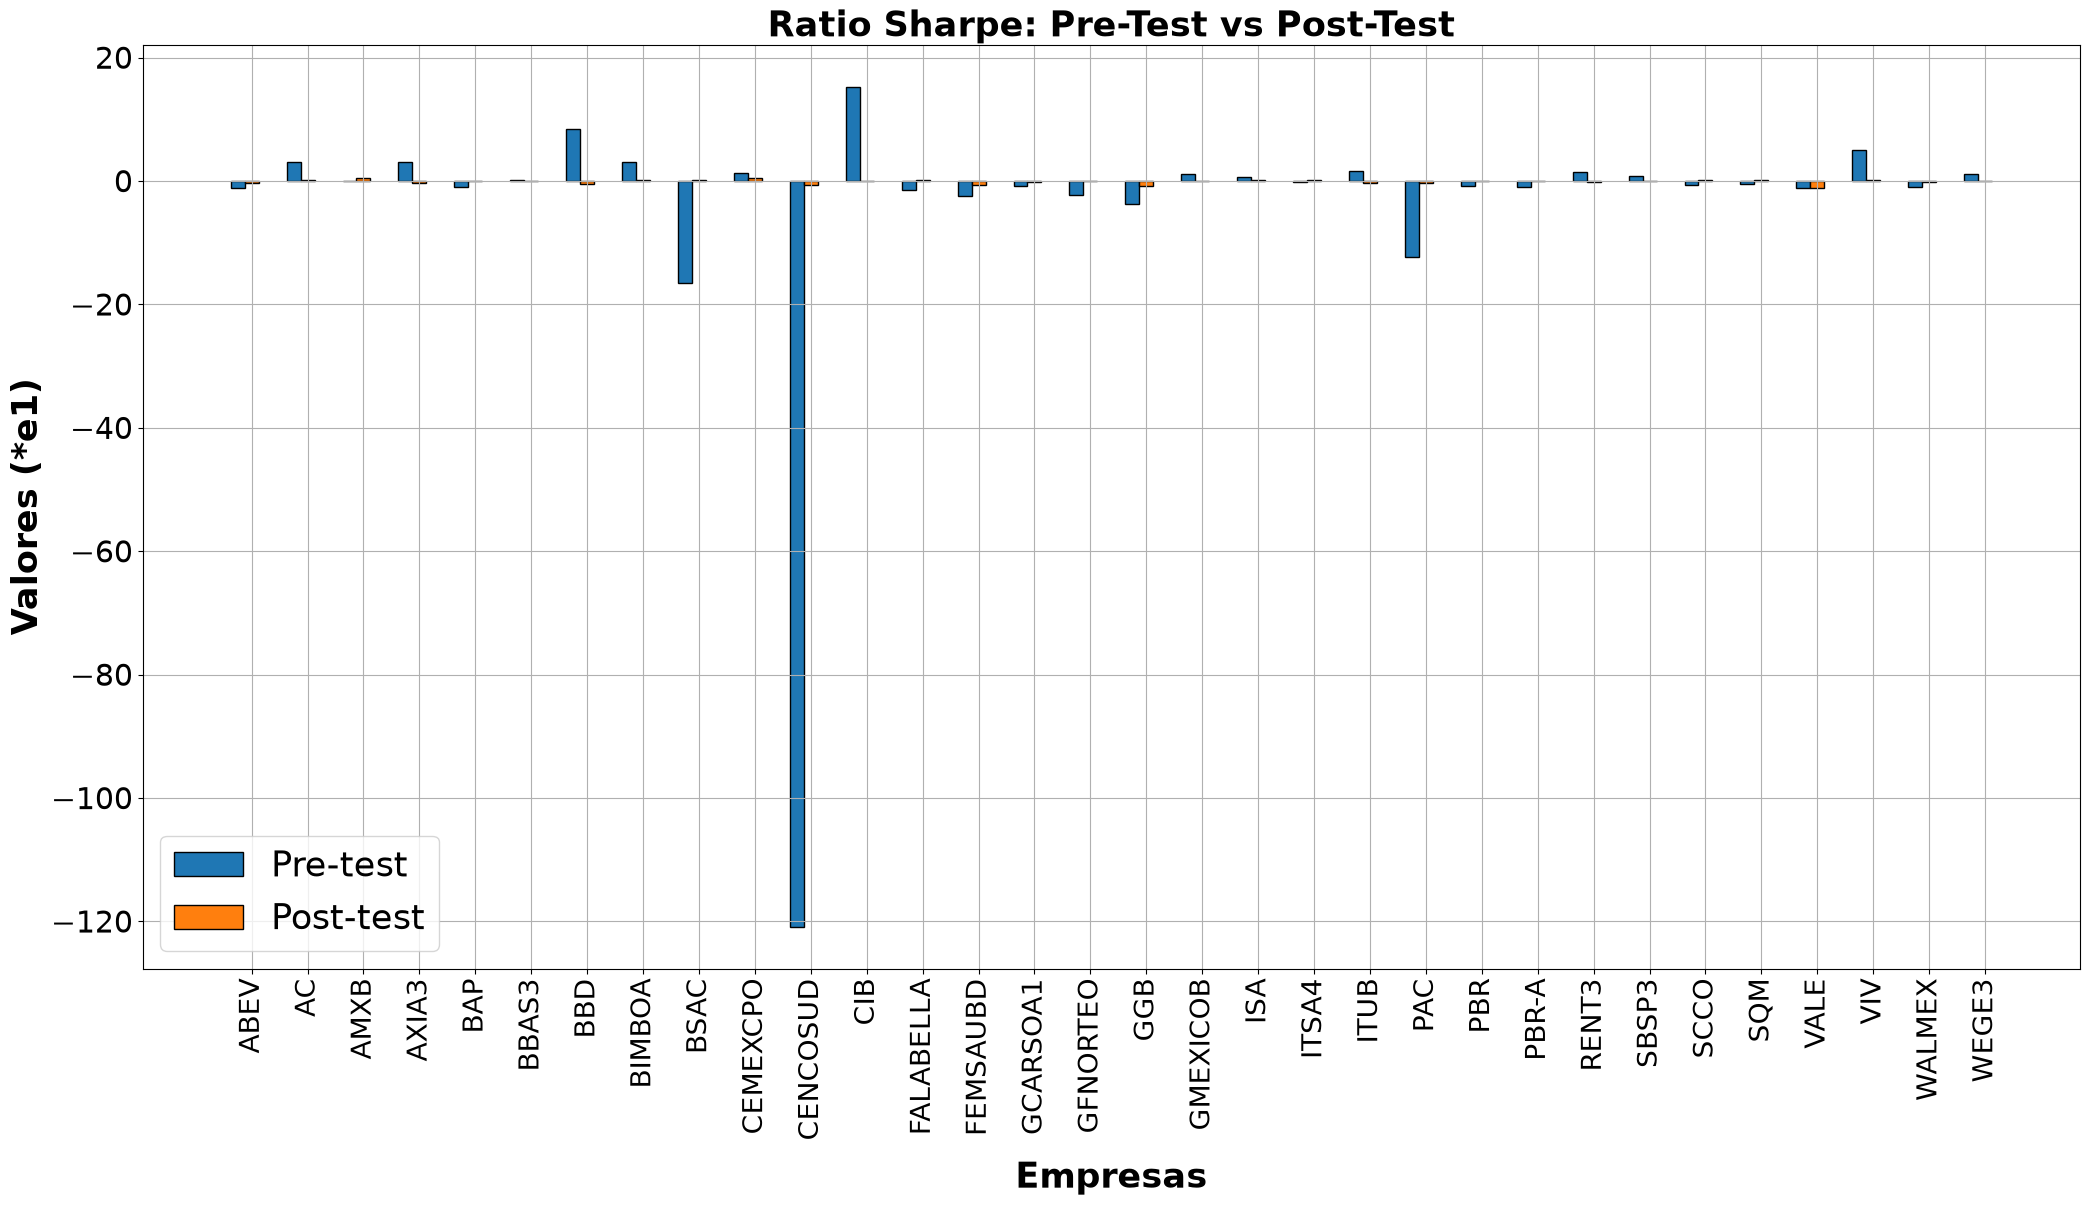

In [436]:
#### Evalauciones
### Analisis del pre-test
indice_rend_pre, indice_vol_pre, indice_rs_pre = test(rend_diaria_original_rand, rend_diaria_original_lstm)
pre_rend_estad  = estadisticas(indice_rend_pre)
pre_vol_estad  = estadisticas(indice_vol_pre)
pre_rs_estad = estadisticas(indice_rs_pre)
# display(indice_rs_pre)
# display(indice_rend_pre.mean(axis=0))
# print(pre_rs_estad)


# ### Analisis del post-test
indice_rend_post, indice_vol_post, indice_rs_post = test(rend_diaria_original_rand, rend_diaria_original_todo)
post_rend_estad = estadisticas(indice_rend_post)
post_vol_estad = estadisticas(indice_vol_post)
post_rs_estad = estadisticas(indice_rs_post)
# display(indice_rs_post.mean(axis=0))
# print(post_rs_estad)


### Crecimientos
# crecimientos(indice_rend_pre, indice_rend_post, "Rendimiento")
# crecimientos(indice_vol_pre, indice_vol_post, "Volatilidad")
crecimientos(indice_rs_pre, indice_rs_post, "Ratio Sharpe")


# ### Visuales de estadisticas
# # visuales(pre_rend_estad, post_rend_estad, "Rendimiento")
# visuales(pre_vol_estad, post_vol_estad, 'Volatilidad')
# # visuales(pre_rs_estad, post_rs_estad, 'Ratio Sharpe')

# ### Distribucion
# # distribucion(indice_rend_pre, indice_rend_post, "Rendimiento")
# distribucion(indice_vol_pre, indice_vol_post, "Volatilidad")

# ### Normalidad
# # normalidad(indice_rend_pre, indice_rend_post, 'Rendimiento')
# normalidad(indice_vol_pre, indice_vol_post, 'Volatilidad')

# ### Wilcoxon
# # wilcoxon(indice_rend_pre, indice_rend_post, 'Rendimiento')
# wilcoxon(indice_vol_pre, indice_vol_post, 'Volatilidad')